Simulating NRZ encoding for binary sequence: 0100110
NRZ-L encoded: [-1, 1, -1, -1, 1, 1, -1]
NRZ-I encoded: [-1, 1, 1, 1, -1, 1, 1]


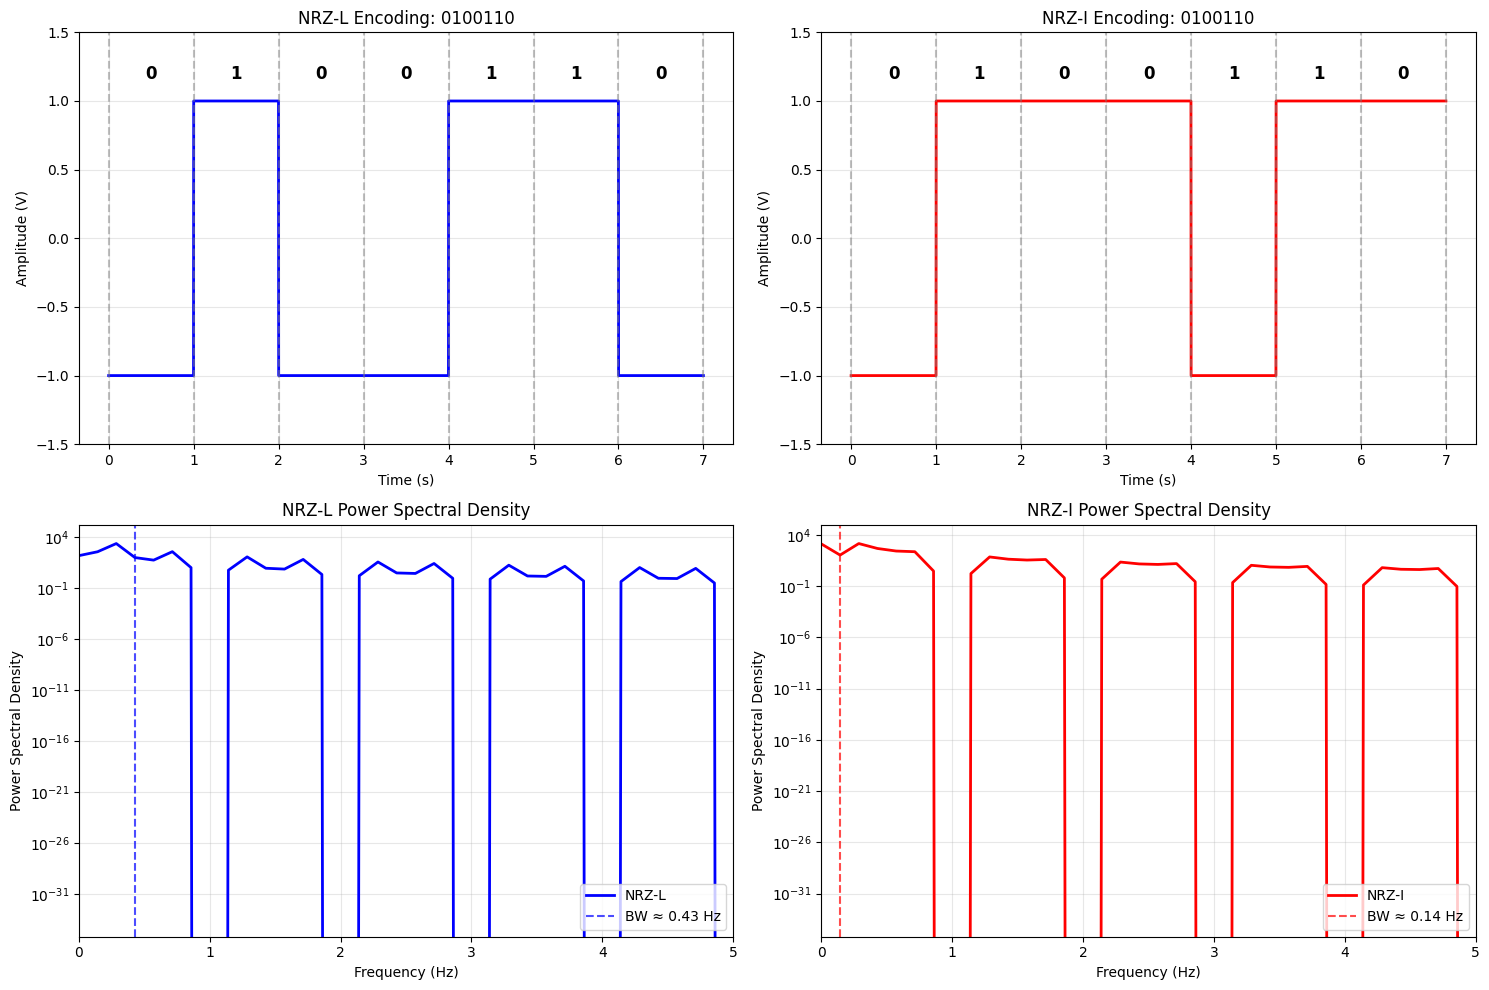


BANDWIDTH ANALYSIS:
NRZ-L First Null Bandwidth: 0.43 Hz
NRZ-I First Null Bandwidth: 0.14 Hz
Bandwidth Ratio (NRZ-I/NRZ-L): 0.33

Theoretical NRZ Bandwidth (R/2): 0.50 Hz
Where R = bit rate = 1.00 bps

TRANSITION ANALYSIS:
NRZ-L transitions: 4
NRZ-I transitions: 3
Higher transitions generally mean higher bandwidth requirements

TESTING WITH DIFFERENT PATTERNS:

Alternating pattern (worst case):
Simulating NRZ encoding for binary sequence: 0101010
NRZ-L encoded: [-1, 1, -1, 1, -1, 1, -1]
NRZ-I encoded: [-1, 1, 1, -1, -1, 1, 1]


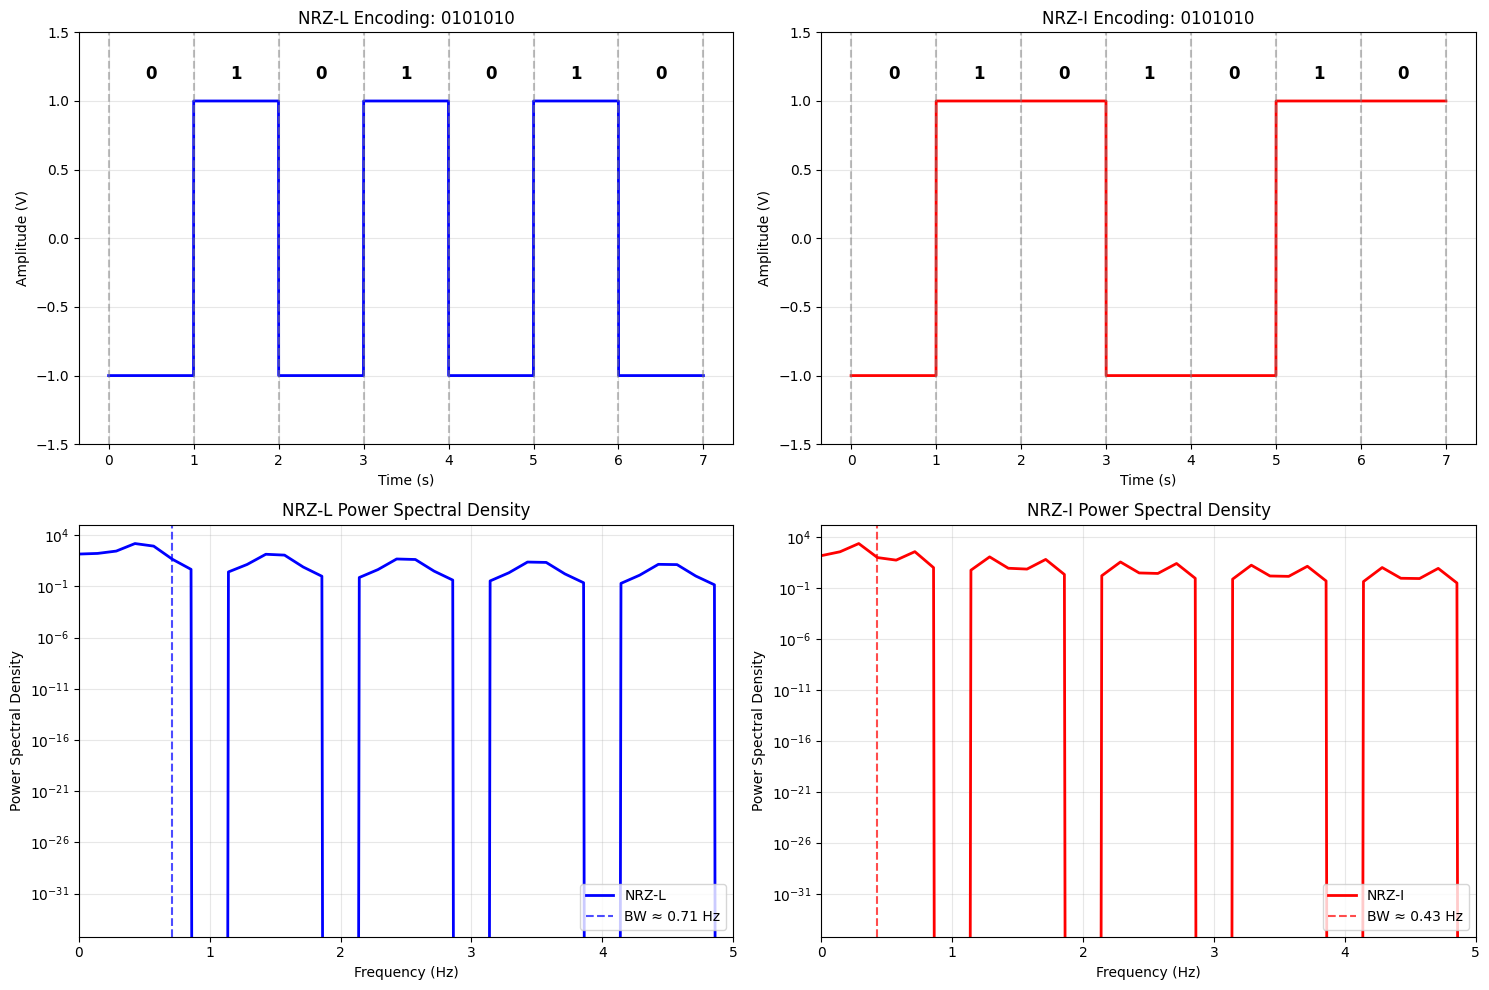


BANDWIDTH ANALYSIS:
NRZ-L First Null Bandwidth: 0.71 Hz
NRZ-I First Null Bandwidth: 0.43 Hz
Bandwidth Ratio (NRZ-I/NRZ-L): 0.60

Theoretical NRZ Bandwidth (R/2): 0.50 Hz
Where R = bit rate = 1.00 bps

TRANSITION ANALYSIS:
NRZ-L transitions: 6
NRZ-I transitions: 3
Higher transitions generally mean higher bandwidth requirements

All ones pattern:
Simulating NRZ encoding for binary sequence: 1111111
NRZ-L encoded: [1, 1, 1, 1, 1, 1, 1]
NRZ-I encoded: [1, -1, 1, -1, 1, -1, 1]


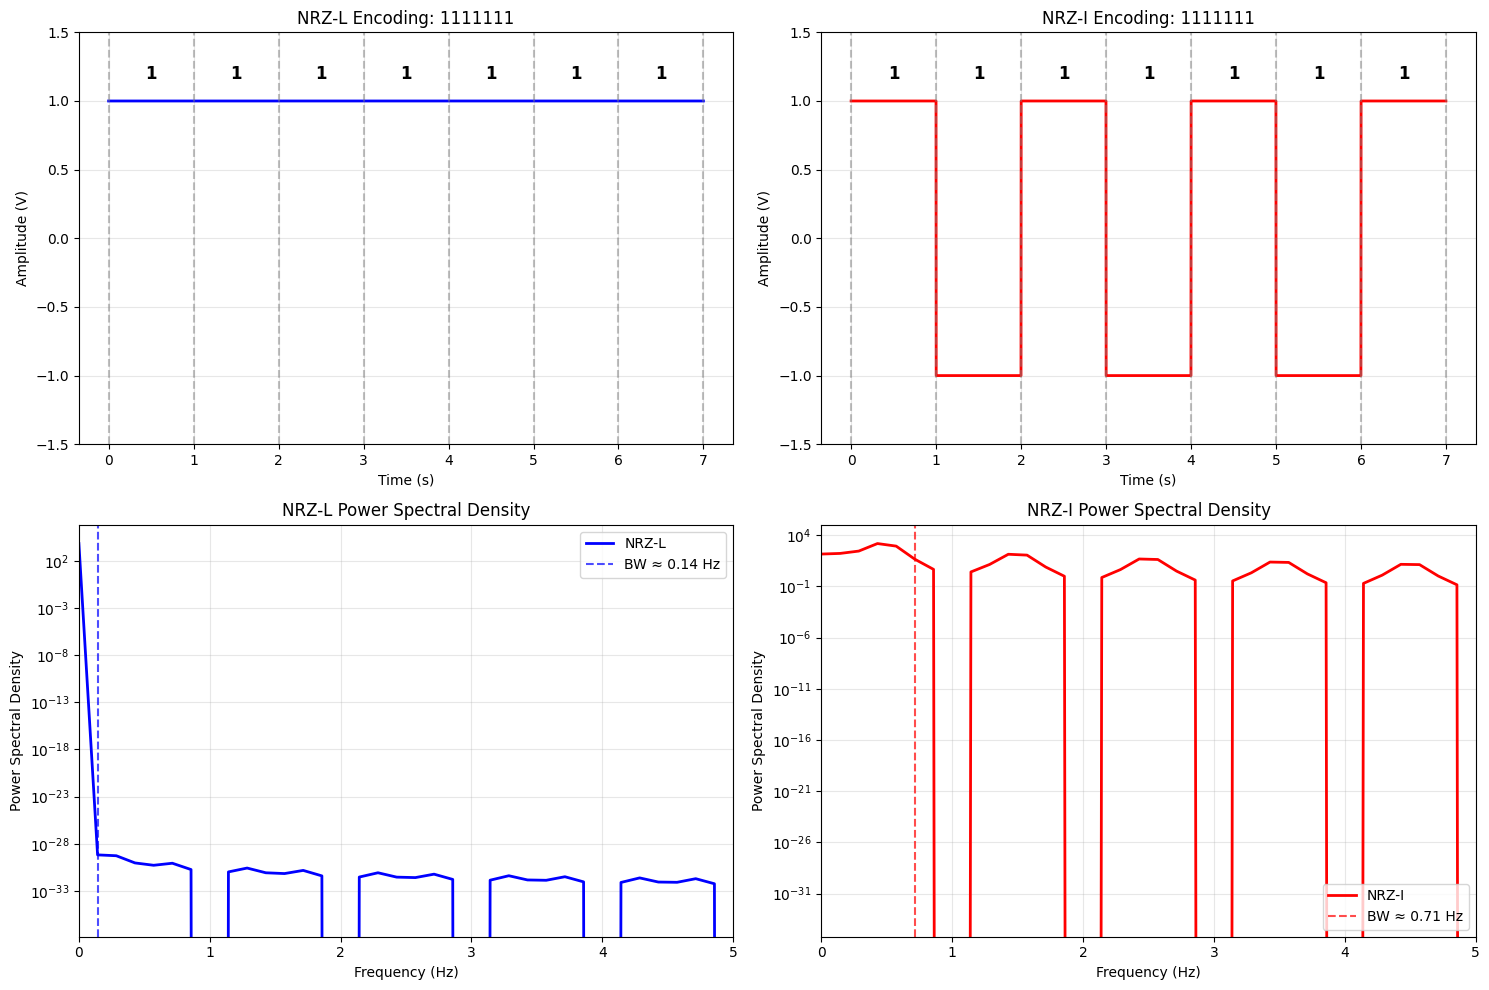


BANDWIDTH ANALYSIS:
NRZ-L First Null Bandwidth: 0.14 Hz
NRZ-I First Null Bandwidth: 0.71 Hz
Bandwidth Ratio (NRZ-I/NRZ-L): 5.00

Theoretical NRZ Bandwidth (R/2): 0.50 Hz
Where R = bit rate = 1.00 bps

TRANSITION ANALYSIS:
NRZ-L transitions: 0
NRZ-I transitions: 6
Higher transitions generally mean higher bandwidth requirements

All zeros pattern:
Simulating NRZ encoding for binary sequence: 0000000
NRZ-L encoded: [-1, -1, -1, -1, -1, -1, -1]
NRZ-I encoded: [-1, -1, -1, -1, -1, -1, -1]


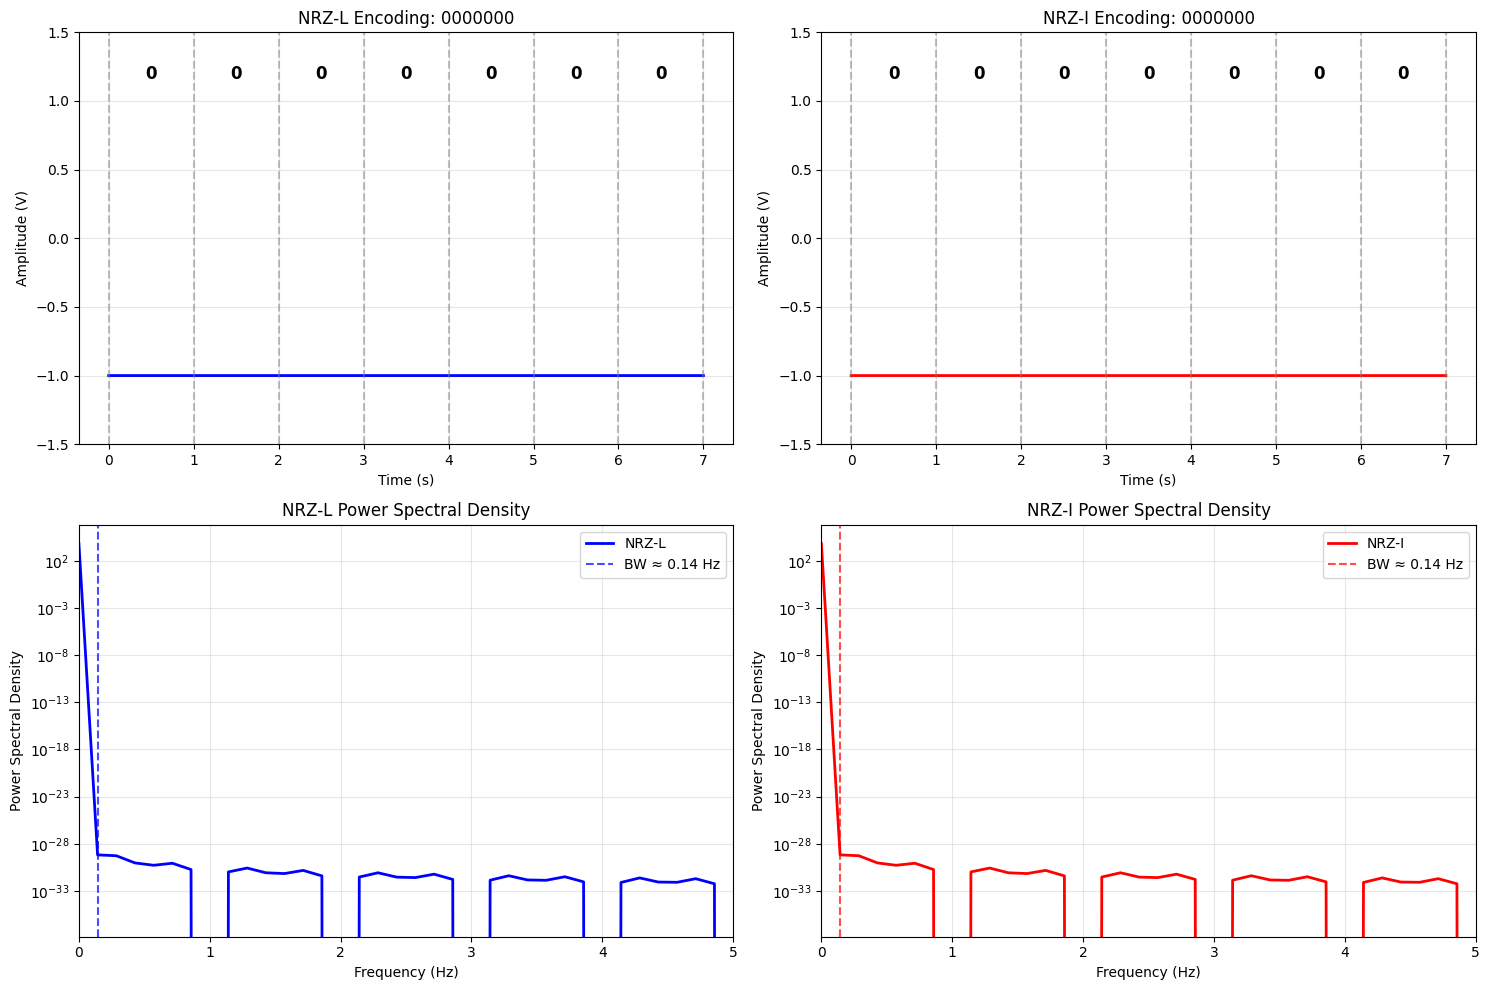


BANDWIDTH ANALYSIS:
NRZ-L First Null Bandwidth: 0.14 Hz
NRZ-I First Null Bandwidth: 0.14 Hz
Bandwidth Ratio (NRZ-I/NRZ-L): 1.00

Theoretical NRZ Bandwidth (R/2): 0.50 Hz
Where R = bit rate = 1.00 bps

TRANSITION ANALYSIS:
NRZ-L transitions: 0
NRZ-I transitions: 0
Higher transitions generally mean higher bandwidth requirements


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

def nrz_l_encode(binary_seq):
    """
    NRZ-L (Non-Return-to-Zero Level) encoding:
    - '1' is represented by positive voltage (+1)
    - '0' is represented by negative voltage (-1)
    """
    return [1 if bit == '1' else -1 for bit in binary_seq]

def nrz_i_encode(binary_seq):
    """
    NRZ-I (Non-Return-to-Zero Inverted) encoding:
    - '1' causes a transition (invert the previous state)
    - '0' maintains the previous state
    Starting with initial state of -1
    """
    encoded = []
    current_state = -1  # Initial state

    for bit in binary_seq:
        if bit == '1':
            current_state = -current_state  # Transition for '1'
        encoded.append(current_state)  # Maintain state for '0'

    return encoded

def create_waveform(encoded_bits, bit_duration=1, sample_rate=100):
    """
    Create time-domain waveform from encoded bits
    """
    samples_per_bit = int(bit_duration * sample_rate)
    total_samples = len(encoded_bits) * samples_per_bit

    t = np.linspace(0, len(encoded_bits) * bit_duration, total_samples, endpoint=False)
    waveform = np.repeat(encoded_bits, samples_per_bit)

    return t, waveform

def calculate_bandwidth(waveform, sample_rate):
    """
    Calculate bandwidth using FFT analysis
    Returns frequency array and power spectral density
    """
    n = len(waveform)
    fft_vals = fft(waveform)
    freqs = fftfreq(n, 1/sample_rate)

    # Calculate power spectral density
    psd = np.abs(fft_vals)**2 / n

    # Only return positive frequencies
    pos_freqs = freqs[:n//2]
    pos_psd = psd[:n//2]

    return pos_freqs, pos_psd

def find_null_bandwidth(freqs, psd, threshold=0.1):
    """
    Find the first null bandwidth (where PSD drops below threshold of max)
    """
    max_psd = np.max(psd)
    threshold_val = threshold * max_psd

    # Find first frequency where PSD drops below threshold
    for i, p in enumerate(psd):
        if i > 0 and p < threshold_val:  # Skip DC component
            return freqs[i]

    return freqs[-1]  # Return max frequency if no null found

# Main simulation
def simulate_nrz_encoding(binary_sequence="0100110"):
    print(f"Simulating NRZ encoding for binary sequence: {binary_sequence}")

    # Encoding
    nrz_l = nrz_l_encode(binary_sequence)
    nrz_i = nrz_i_encode(binary_sequence)

    print(f"NRZ-L encoded: {nrz_l}")
    print(f"NRZ-I encoded: {nrz_i}")

    # Create waveforms
    bit_duration = 1  # 1 second per bit
    sample_rate = 1000  # 1000 samples per second

    t_l, wave_l = create_waveform(nrz_l, bit_duration, sample_rate)
    t_i, wave_i = create_waveform(nrz_i, bit_duration, sample_rate)

    # Calculate frequency domain
    freqs_l, psd_l = calculate_bandwidth(wave_l, sample_rate)
    freqs_i, psd_i = calculate_bandwidth(wave_i, sample_rate)

    # Find bandwidth metrics
    bw_l = find_null_bandwidth(freqs_l, psd_l)
    bw_i = find_null_bandwidth(freqs_i, psd_i)

    # Create plots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

    # Plot NRZ-L waveform
    ax1.plot(t_l, wave_l, 'b-', linewidth=2, label='NRZ-L')
    ax1.set_title(f'NRZ-L Encoding: {binary_sequence}')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude (V)')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-1.5, 1.5)

    # Add bit boundaries and labels
    for i, bit in enumerate(binary_sequence):
        ax1.axvline(x=i, color='gray', linestyle='--', alpha=0.5)
        ax1.text(i+0.5, 1.2, bit, ha='center', va='center', fontsize=12, fontweight='bold')
    ax1.axvline(x=len(binary_sequence), color='gray', linestyle='--', alpha=0.5)

    # Plot NRZ-I waveform
    ax2.plot(t_i, wave_i, 'r-', linewidth=2, label='NRZ-I')
    ax2.set_title(f'NRZ-I Encoding: {binary_sequence}')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Amplitude (V)')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(-1.5, 1.5)

    # Add bit boundaries and labels
    for i, bit in enumerate(binary_sequence):
        ax2.axvline(x=i, color='gray', linestyle='--', alpha=0.5)
        ax2.text(i+0.5, 1.2, bit, ha='center', va='center', fontsize=12, fontweight='bold')
    ax2.axvline(x=len(binary_sequence), color='gray', linestyle='--', alpha=0.5)

    # Plot frequency domain - NRZ-L
    ax3.semilogy(freqs_l, psd_l, 'b-', linewidth=2, label='NRZ-L')
    ax3.set_title('NRZ-L Power Spectral Density')
    ax3.set_xlabel('Frequency (Hz)')
    ax3.set_ylabel('Power Spectral Density')
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 5)  # Limit to first few Hz for clarity
    ax3.axvline(x=bw_l, color='blue', linestyle='--', alpha=0.7, label=f'BW ≈ {bw_l:.2f} Hz')
    ax3.legend()

    # Plot frequency domain - NRZ-I
    ax4.semilogy(freqs_i, psd_i, 'r-', linewidth=2, label='NRZ-I')
    ax4.set_title('NRZ-I Power Spectral Density')
    ax4.set_xlabel('Frequency (Hz)')
    ax4.set_ylabel('Power Spectral Density')
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, 5)  # Limit to first few Hz for clarity
    ax4.axvline(x=bw_i, color='red', linestyle='--', alpha=0.7, label=f'BW ≈ {bw_i:.2f} Hz')
    ax4.legend()

    plt.tight_layout()
    plt.show()

    # Print bandwidth comparison
    print("\n" + "="*50)
    print("BANDWIDTH ANALYSIS:")
    print("="*50)
    print(f"NRZ-L First Null Bandwidth: {bw_l:.2f} Hz")
    print(f"NRZ-I First Null Bandwidth: {bw_i:.2f} Hz")
    print(f"Bandwidth Ratio (NRZ-I/NRZ-L): {bw_i/bw_l:.2f}")

    # Theoretical bandwidth for NRZ (bit rate / 2)
    bit_rate = 1 / bit_duration  # bits per second
    theoretical_bw = bit_rate / 2
    print(f"\nTheoretical NRZ Bandwidth (R/2): {theoretical_bw:.2f} Hz")
    print(f"Where R = bit rate = {bit_rate:.2f} bps")

    # Pattern analysis
    transitions_l = sum(1 for i in range(1, len(nrz_l)) if nrz_l[i] != nrz_l[i-1])
    transitions_i = sum(1 for i in range(1, len(nrz_i)) if nrz_i[i] != nrz_i[i-1])

    print(f"\nTRANSITION ANALYSIS:")
    print(f"NRZ-L transitions: {transitions_l}")
    print(f"NRZ-I transitions: {transitions_i}")
    print(f"Higher transitions generally mean higher bandwidth requirements")

# Run simulation with default sequence
if __name__ == "__main__":
    # Test with default sequence
    simulate_nrz_encoding("0100110")


    #testing

    print("\n" + "="*70)
    print("TESTING WITH DIFFERENT PATTERNS:")
    print("="*70)

    # Test with alternating pattern (worst case for bandwidth)
    print("\nAlternating pattern (worst case):")
    simulate_nrz_encoding("0101010")

    # Test with all ones
    print("\nAll ones pattern:")
    simulate_nrz_encoding("1111111")

    # Test with all zeros
    print("\nAll zeros pattern:")
    simulate_nrz_encoding("0000000")